<div class="alert" style="background-color: #fff1f2; color: #9f1239; border-left: 6px solid #e11d48; border-top: 1px solid #fecdd3; border-right: 1px solid #fecdd3; border-bottom: 1px solid #fecdd3; border-radius: 8px; padding: 18px 22px; box-shadow: 0 4px 6px -1px rgba(225, 29, 72, 0.08); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;" id="my-bookmark">
    <div style="font-size: 12px; font-weight: 700; letter-spacing: 0.8px; text-transform: uppercase; color: #e11d48; margin-bottom: 6px;">
        GOAL:
    </div>
    <div style="font-size: 16px; font-weight: 600; line-height: 1.5;">
        How do air quality patterns correlate with disease prevalence or healthcare utilization?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

data = pd.read_pickle('all_clean_dfs.pkl')
globals().update(data)
all_dfs = data

In [2]:
health_dfs = {
    "Asthma ED Visits due to PM2.5": asth_pm_df,
    "Asthma Hospitalizations due to Ozone": asth_oz_h_df,
    "Asthma ED Visits due to Ozone": asth_oz_ed_df,
    "Respiratory Hospitalizations due to PM2.5 (Age 20+)": resp_df,
    "Cardiovascular Hospitalizations due to PM2.5 (Age 40+)": cardio_df,
    "Deaths due to PM2.5": deaths_pm_df,
    "Cardiac & Respiratory Deaths due to Ozone": deaths_oz_df,
}

In [3]:
pollu_dfs = {
    "Nitrogen Dioxide (NO₂)": no2_df,
    "Fine Particles (PM₂.5)": pm25_df,
    "Ozone (O₃)": ozone_df,
    "Boiler Emissions - Total SO₂": so2_em_df,
    "Boiler Emissions - Total NOₓ": nox_em_df,
    "Boiler Emissions - Total PM₂.5": pm25_em_df,
    "Air Toxics - Formaldehyde": form_df,
    "Air Toxics - Benzene": benz_df,
    "Annual VMT (Total)": vmt_df,
    "Annual VMT (Cars)": vmt_cars_df,
    "Annual VMT (Trucks)": vmt_trck_df,
}

In [4]:
pivoted_df = clean_df.pivot_table( index="Geo Place Name", columns="Name", values="Data Value", aggfunc="mean" ) 

name_mapping = { 'Nitrogen dioxide (NO2)': 'NO2 Levels', 'Fine particles (PM 2.5)': 'PM2.5 Levels', 
                 'Boiler Emissions- Total SO2 Emissions': 'Boiler SO2', 'Ozone (O3)': 'Ozone Levels', 
                 'Asthma emergency department visits due to PM2.5': 'Asthma ED (PM2.5)', 'Annual vehicle miles traveled': 'VMT Total', 
                 'Respiratory hospitalizations due to PM2.5 (age 20+)': 'Resp Hosp (PM2.5)', 
                 'Asthma hospitalizations due to Ozone': 'Asthma Hosp (Ozone)', 'Boiler Emissions- Total NOx Emissions': 'Boiler NOx',
                 'Boiler Emissions- Total PM2.5 Emissions': 'Boiler PM2.5', 'Outdoor Air Toxics - Formaldehyde': 'Formaldehyde', 
                 'Outdoor Air Toxics - Benzene': 'Benzene', 'Asthma emergency departments visits due to Ozone': 'Asthma ED (Ozone)',
                 'Annual vehicle miles traveled (cars)': 'VMT Cars', 'Annual vehicle miles traveled (trucks)': 'VMT Trucks',
                 'Cardiovascular hospitalizations due to PM2.5 (age 40+)': 'Cardio Hosp (PM2.5)', 'Deaths due to PM2.5': 'Deaths (PM2.5)', 
                 'Cardiac and respiratory deaths due to Ozone': 'Deaths (Ozone)' } 
pivoted_df = pivoted_df.rename(columns=name_mapping) 

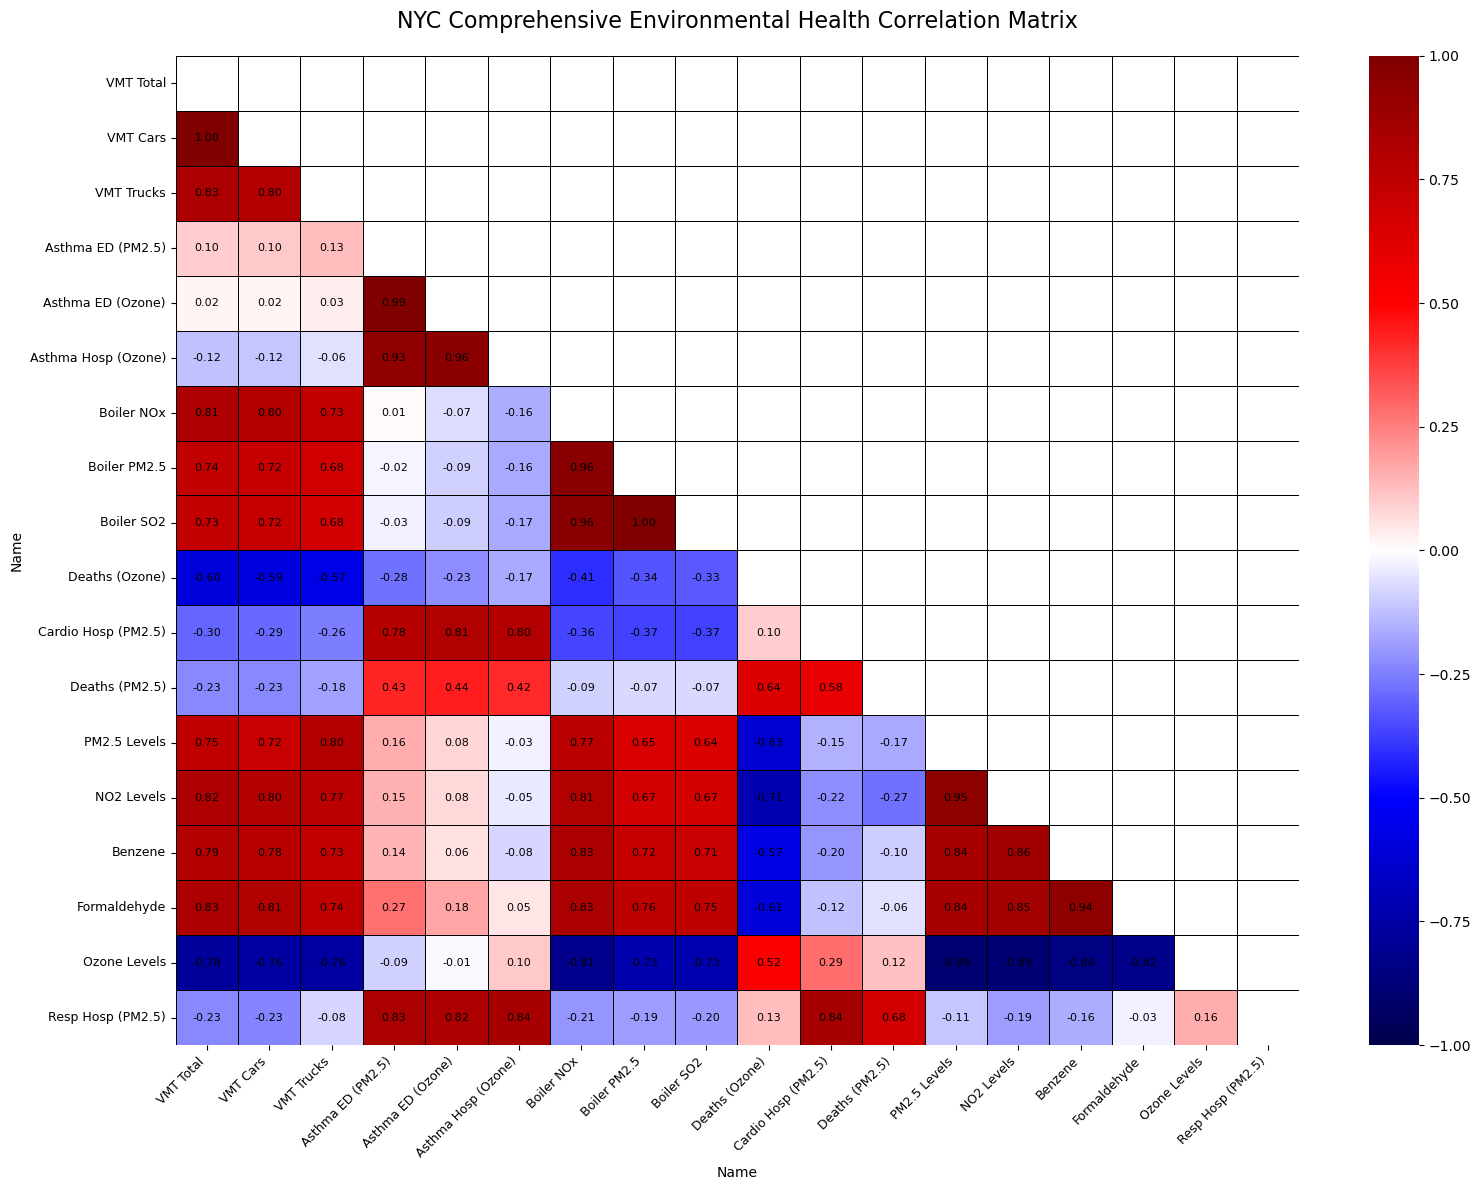

In [5]:
# heat map of envronmental & health variables
corr_matrix = pivoted_df.corr() 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
plt.figure(figsize=(16, 12)) 
sns.heatmap( corr_matrix, mask=mask, cmap='seismic', linewidths=0.5, linecolor='black', cbar=True, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={'size': 8, 'color': 'black'} ) 
plt.xticks(rotation=45, ha='right', fontsize=9) 
plt.yticks(rotation=0, fontsize=9) 
plt.title('NYC Comprehensive Environmental Health Correlation Matrix', size=16, pad=20) 
plt.tight_layout() 
plt.show() 

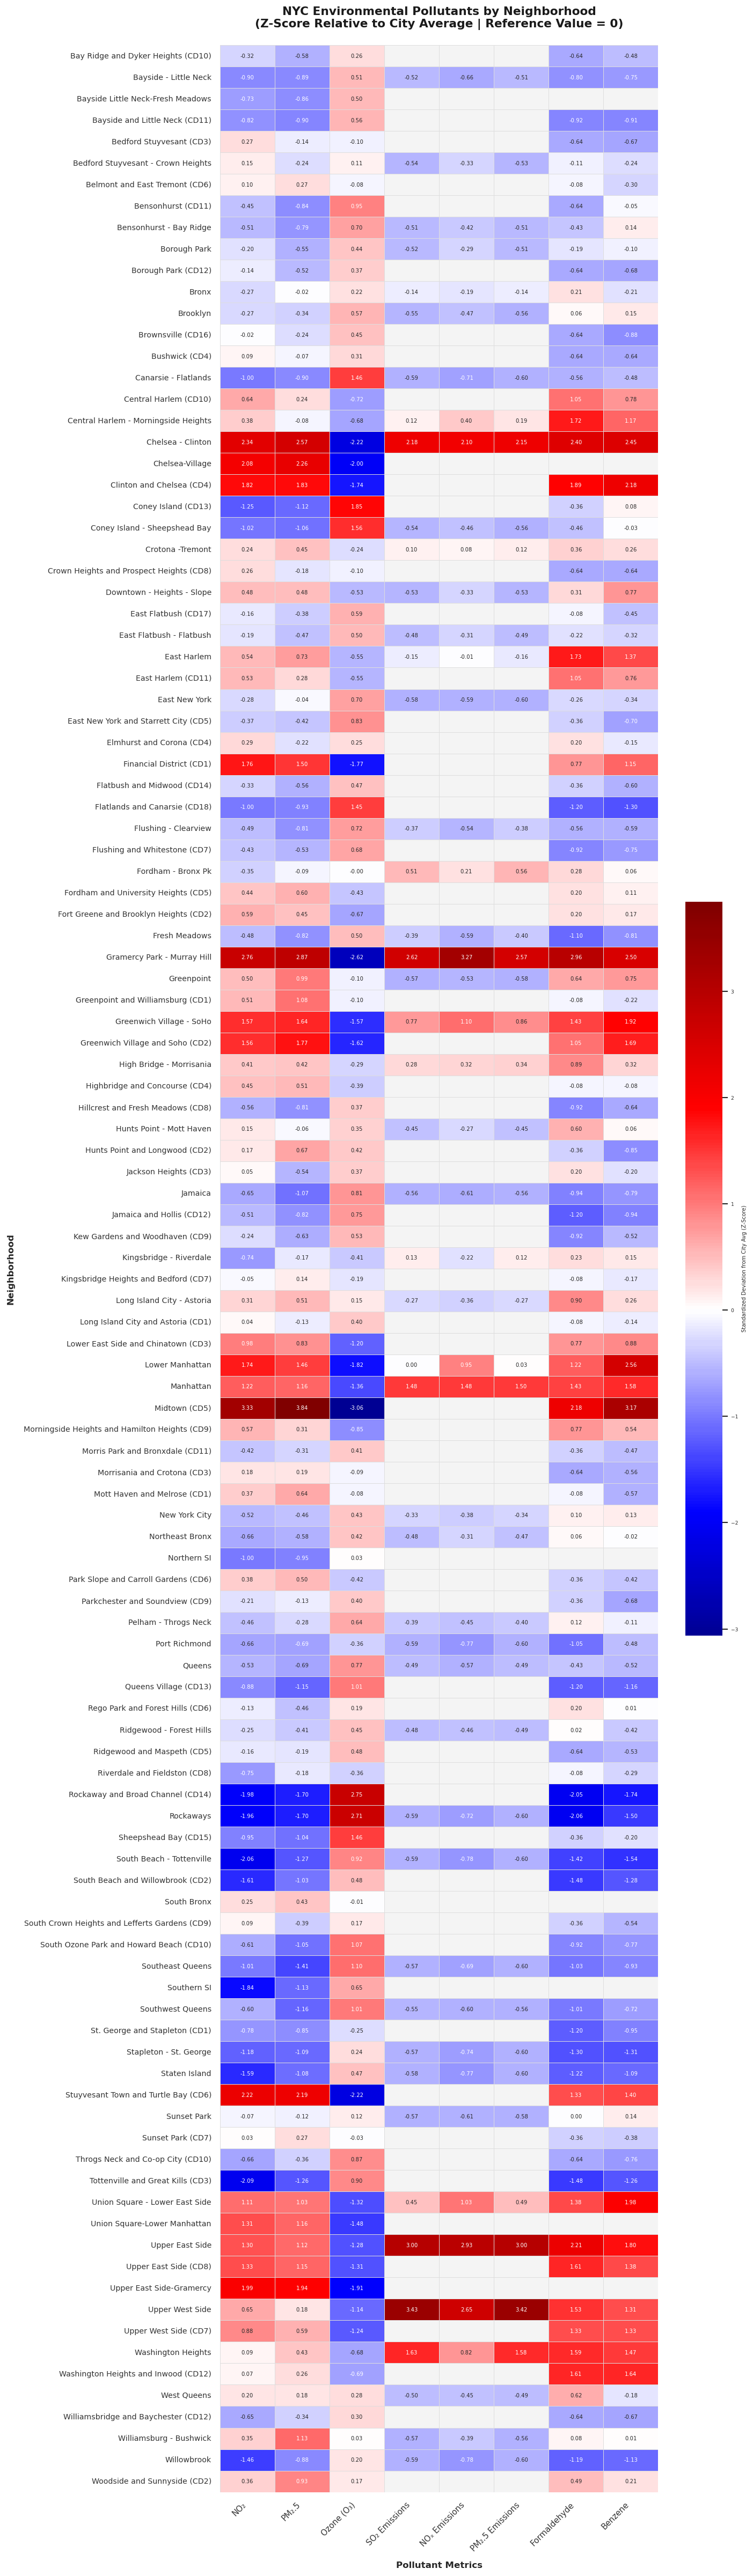

In [6]:
# 1. Define pollutant metrics and readable names
pollu_labels = {
    "no2_df": "NO₂",
    "pm25_df": "PM₂.5",
    "ozone_df": "Ozone (O₃)",
    "so2_em_df": "SO₂ Emissions",
    "nox_em_df": "NOₓ Emissions",
    "pm25_em_df": "PM₂.5 Emissions",
    "form_df": "Formaldehyde",
    "benz_df": "Benzene",
}

# 2. Merge all pollutant dataframes into a wide table
pollu_data = pd.DataFrame()

for key, label in pollu_labels.items():
    if key in all_dfs and isinstance(all_dfs[key], pd.DataFrame):
        df = all_dfs[key]
        val_col = next(
            (
                c
                for c in [
                    "Data Value",
                    "Value",
                    "Estimated Annual Rate per 100,000",
                    "Mean",
                    "Amount",
                ]
                if c in df.columns
            ),
            None,
        )
        if val_col and "Geo Place Name" in df.columns:
            sub = (
                df.dropna(subset=[val_col, "Geo Place Name"])
                .groupby("Geo Place Name")[val_col]
                .mean()
                .reset_index(name=label)
            )
            if pollu_data.empty:
                pollu_data = sub
            else:
                pollu_data = pd.merge(
                    pollu_data, sub, on="Geo Place Name", how="outer"
                )

# Set neighborhood as index
matrix_df = pollu_data.set_index("Geo Place Name")

# 3. Standardize to Z-scores so everything shares a common reference baseline (City Avg = 0)
matrix_zscore = matrix_df.apply(lambda x: (x - x.mean()) / x.std())

# 4. Configure Colormap so missing/empty data cells show up as Solid Black
cmap = plt.get_cmap("seismic").copy()
cmap.set_bad(color="#F4F4F4")

# 5. Plot Heatmap
plt.figure(figsize=(12, 40), dpi=120)
sns.set_theme(style="white", font_scale=0.5)

ax = sns.heatmap(
    matrix_zscore,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Deviation from City Avg (Z-Score)",
        "shrink": 0.3,
    },
)

# Titles and Formatting
plt.title(
    "NYC Environmental Pollutants by Neighborhood\n(Z-Score Relative to City Average | Reference Value = 0)",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

plt.xlabel("Pollutant Metrics", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Neighborhood", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=8.5, color="#333333")

plt.tight_layout()
plt.show()

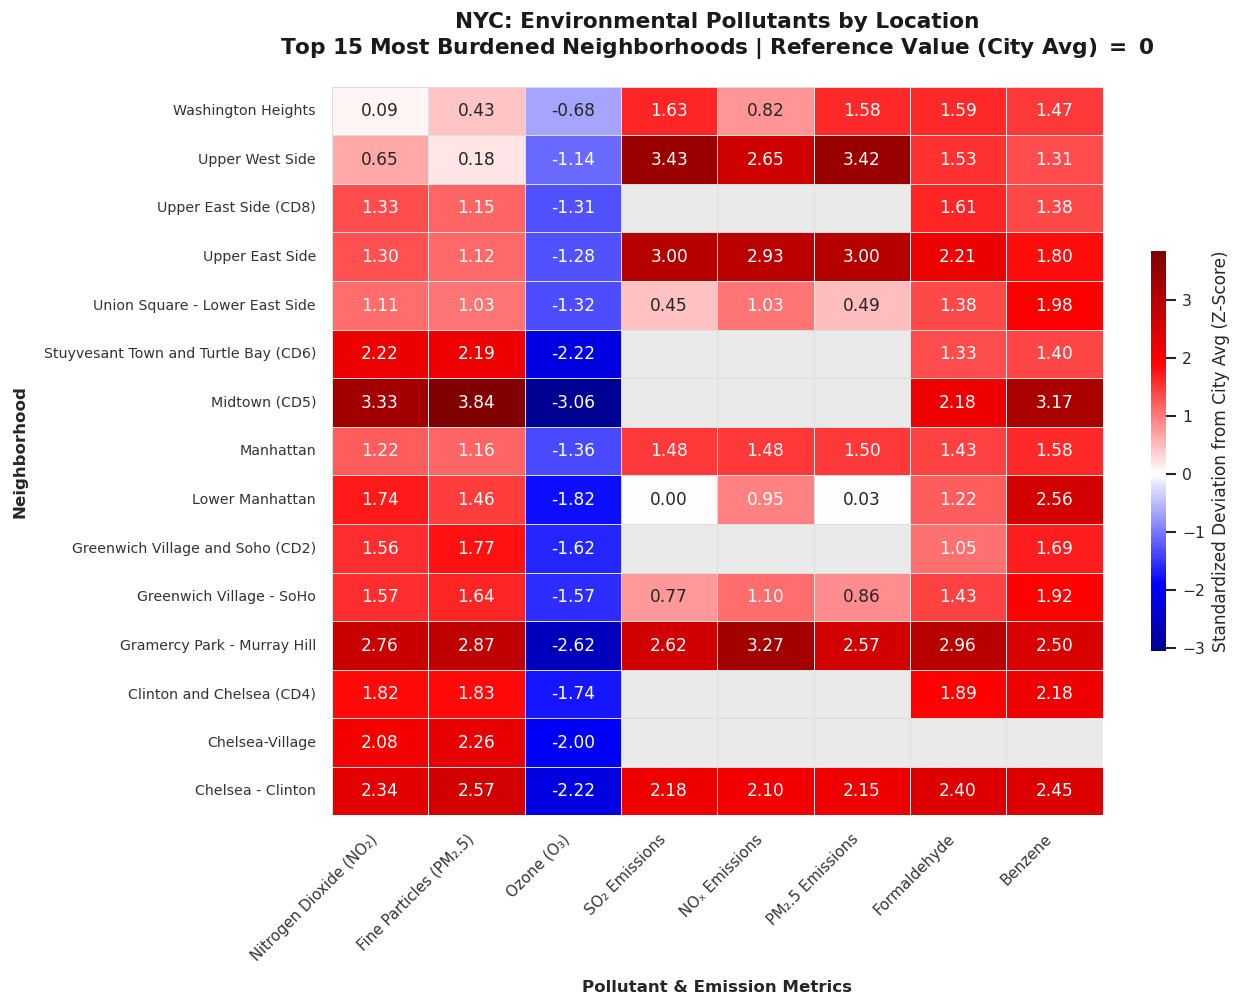

In [7]:
#Variables
pollu_labels = {
    "no2_df": "Nitrogen Dioxide (NO₂)",
    "pm25_df": "Fine Particles (PM₂.5)",
    "ozone_df": "Ozone (O₃)",
    "so2_em_df": "SO₂ Emissions",
    "nox_em_df": "NOₓ Emissions",
    "pm25_em_df": "PM₂.5 Emissions",
    "form_df": "Formaldehyde",
    "benz_df": "Benzene",
}

pollu_data = pd.DataFrame()

for key, label in pollu_labels.items():
    if key in all_dfs and isinstance(all_dfs[key], pd.DataFrame):
        df = all_dfs[key]
        val_col = next(
            (
                c
                for c in [
                    "Data Value",
                    "Value",
                    "Estimated Annual Rate per 100,000",
                    "Mean",
                    "Amount",
                ]
                if c in df.columns
            ),
            None,
        )
        if val_col and "Geo Place Name" in df.columns:
            sub = (
                df.dropna(subset=[val_col, "Geo Place Name"])
                .groupby("Geo Place Name")[val_col]
                .mean()
                .reset_index(name=label)
            )
            if pollu_data.empty:
                pollu_data = sub
            else:
                pollu_data = pd.merge(
                    pollu_data, sub, on="Geo Place Name", how="outer"
                )

# Set neighborhood as index
pollu_matrix = pollu_data.set_index("Geo Place Name")

# Convert to Z-Scores so 0 is the city average
pollu_zscore = pollu_matrix.apply(lambda x: (x - x.mean()) / x.std())

# Calculate overall burden to find the top 15
pollu_zscore["overall_burden"] = pollu_zscore.mean(axis=1)
top_15_locations = (
    pollu_zscore.nlargest(15, "overall_burden")
    .drop(columns=["overall_burden"])
    .sort_index(ascending=False)
)

# Configure Colormap colors
cmap = plt.get_cmap("seismic").copy()
cmap.set_bad(color="#EAEAEA")

#  Heatmap setup
plt.figure(figsize=(11, 8.5), dpi=120)
sns.set_theme(style="white", font_scale=0.85)

ax = sns.heatmap(
    top_15_locations,
    cmap=cmap,
    center=0,  # 0 represents the city average reference baseline
    annot=True,  # Include data numbers within the box
    fmt=".2f",  # Format numbers to 2 decimal places
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Deviation from City Avg (Z-Score)",
        "shrink": 0.55,
        "aspect": 26,
    },
)

# Titles, Subtitle, and Formatting
plt.title(
    "NYC: Environmental Pollutants by Location\n"
    r"$\bf{Top\ 15\ Most\ Burdened\ Neighborhoods\ |\ Reference\ Value\ (City\ Avg)\ =\ 0}$",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

plt.xlabel("Pollutant & Emission Metrics", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Neighborhood", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=8.5, color="#333333")

plt.tight_layout()
plt.show()

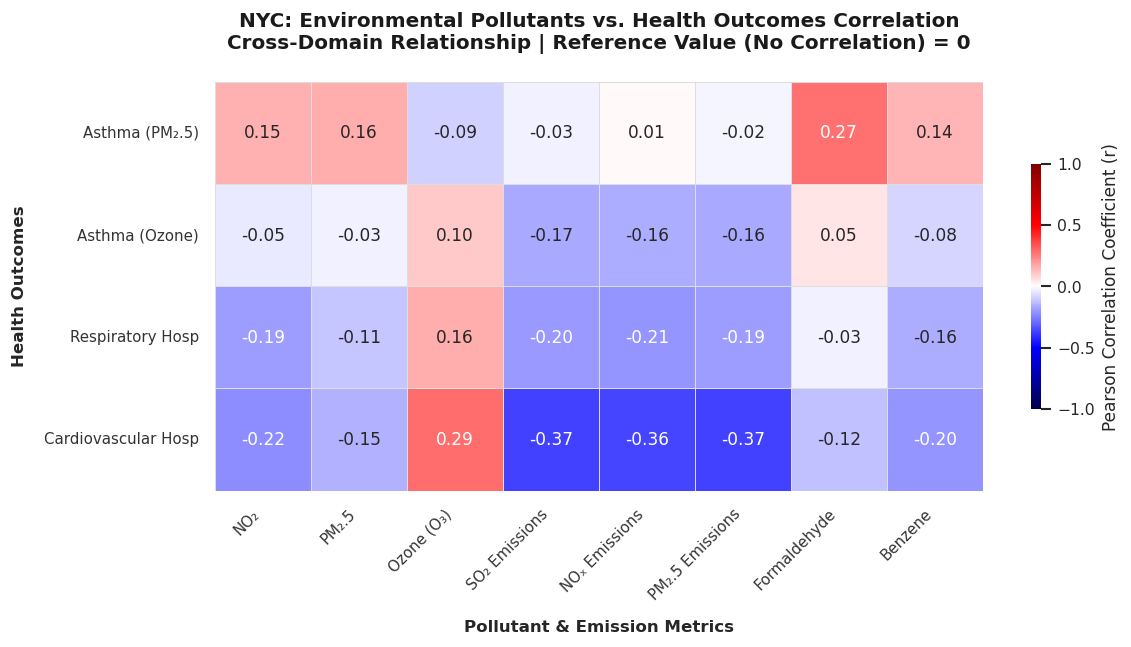

In [8]:
# variables/labels
pollu_labels = {
    "no2_df": "NO₂",
    "pm25_df": "PM₂.5",
    "ozone_df": "Ozone (O₃)",
    "so2_em_df": "SO₂ Emissions",
    "nox_em_df": "NOₓ Emissions",
    "pm25_em_df": "PM₂.5 Emissions",
    "form_df": "Formaldehyde",
    "benz_df": "Benzene",
}

health_labels = {
    "asth_pm_df": "Asthma (PM₂.5)",
    "asth_oz_h_df": "Asthma (Ozone)",
    "resp_df": "Respiratory Hosp",
    "cardio_df": "Cardiovascular Hosp",
}

# merge datasets
master_df = pd.DataFrame()
all_tracked = {**pollu_labels, **health_labels}

for key, label in all_tracked.items():
    if key in all_dfs and isinstance(all_dfs[key], pd.DataFrame):
        df = all_dfs[key]
        val_col = next(
            (
                c
                for c in [
                    "Data Value",
                    "Value",
                    "Estimated Annual Rate per 100,000",
                    "Mean",
                    "Amount",
                ]
                if c in df.columns
            ),
            None,
        )
        if val_col and "Geo Place Name" in df.columns:
            sub = (
                df.dropna(subset=[val_col, "Geo Place Name"])
                .groupby("Geo Place Name")[val_col]
                .mean()
                .reset_index(name=label)
            )
            if master_df.empty:
                master_df = sub
            else:
                master_df = pd.merge(
                    master_df, sub, on="Geo Place Name", how="outer"
                )

if master_df.empty:
    print(
        "Error: master_df is empty. Check if your dataframe keys match all_dfs."
    )
else:
    # Set index
    matrix_df = master_df.set_index("Geo Place Name")

    health_cols = [c for c in health_labels.values() if c in matrix_df.columns]
    pollu_cols = [c for c in pollu_labels.values() if c in matrix_df.columns]

    if not health_cols or not pollu_cols:
        print(
            f"Error: Missing columns. Found health columns: {health_cols}, Found pollutant columns: {pollu_cols}"
        )
    else:
        # Compute correlation matrix
        corr_matrix = matrix_df.corr().loc[health_cols, pollu_cols]

        # colormap
        cmap = plt.get_cmap("seismic").copy()
        cmap.set_bad(color="#EAEAEA")

        # Plot Heatmap
        plt.figure(figsize=(10, 5.5), dpi=120)
        sns.set_theme(style="white", font_scale=0.85)

        ax = sns.heatmap(
            corr_matrix,
            cmap=cmap,
            vmin=-1,
            vmax=1,
            center=0,
            annot=True,
            fmt=".2f",
            square=False,
            linewidths=0.5,
            linecolor="#DDDDDD",
            cbar_kws={
                "label": "Pearson Correlation Coefficient (r)",
                "shrink": 0.6,
                "aspect": 24,
            },
        )

        # Titles and Formatting
        plt.title(
            "NYC: Environmental Pollutants vs. Health Outcomes Correlation\n"
            "Cross-Domain Relationship | Reference Value (No Correlation) = 0",
            fontsize=12,
            fontweight="bold",
            pad=20,
            color="#1A1A1A",
            loc="center",
        )

        plt.xlabel(
            "Pollutant & Emission Metrics", fontsize=10, fontweight="bold", labelpad=10
        )
        plt.ylabel("Health Outcomes", fontsize=10, fontweight="bold", labelpad=10)

        plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
        plt.yticks(rotation=0, fontsize=9, color="#333333")

        plt.tight_layout()
        plt.show()